In [1]:
# Cell 1: Imports and Speed Optimizations
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import cv2, os, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB4
from sklearn.model_selection import train_test_split

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

np.random.seed(42)
tf.random.set_seed(42)
print(f'TF Version: {tf.__version__} | GPU Available: {len(tf.config.list_physical_devices("GPU")) > 0}')

2026-03-30 05:21:09.967173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774848070.182611      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774848070.241390      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774848070.746581      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774848070.746618      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774848070.746621      55 computation_placer.cc:177] computation placer alr

TF Version: 2.19.0 | GPU Available: True


In [2]:
# Cell 2: Hardcoded Paths for Zero-Delay Connection!
aptos_img_dir = '/kaggle/input/datasets/jeetpaghdar/aptos-preprocessed-train-images'
eyepacs_img_dir = '/kaggle/input/datasets/jeetpaghdar/eyepacs-preprocessed-train/eyepacs_images'

In [3]:
# Cell 3: Load Data and Stratified Split
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Exact, literal Kaggle Paths from our deep-scan!
aptos_csv_path = '/kaggle/input/competitions/aptos2019-blindness-detection/train.csv'
aptos_img_dir = '/kaggle/input/datasets/jeetpaghdar/aptos-preprocessed-train'

eyepacs_csv_path = '/kaggle/input/datasets/jeetpaghdar/eyepacs-preprocessed-train/filtered_labels.csv'
eyepacs_img_dir = '/kaggle/input/datasets/jeetpaghdar/eyepacs-preprocessed-train/eyepacs_images'

# 2. Load APTOS Data
aptos_csv = pd.read_csv(aptos_csv_path)
aptos_csv['image_path'] = aptos_csv['id_code'].apply(lambda x: os.path.join(aptos_img_dir, f'{x}.png'))

# 3. Load EyePACS Data
eyepacs_csv = pd.read_csv(eyepacs_csv_path)
eyepacs_csv['image_path'] = eyepacs_csv['id_code'].apply(lambda x: os.path.join(eyepacs_img_dir, f'{x}.png'))

# 4. Combine and filter out broken files
train_csv_combo = pd.concat([aptos_csv, eyepacs_csv], ignore_index=True)
train_csv_combo = train_csv_combo[train_csv_combo['image_path'].apply(os.path.exists)].reset_index(drop=True)

# 5. Split into training and validation
train_df, val_df = train_test_split(
    train_csv_combo, test_size=0.20,
    stratify=train_csv_combo['diagnosis'], random_state=42
)

# 6. Verify our split!
print("Total images effectively loaded:", len(train_csv_combo))
print("\n--- Training Set Class Distribution ---")
print(train_df['diagnosis'].value_counts().sort_index())

Total images effectively loaded: 7686

--- Training Set Class Distribution ---
diagnosis
0    1444
1    2250
2     799
3     853
4     802
Name: count, dtype: int64


In [4]:
# Cell 4: Build tf.data Datasets + Augmentations
tf.keras.backend.clear_session()
IMG_SIZE, BATCH_SIZE = 380, 16

def oversample_df(df):
    max_count = df['diagnosis'].value_counts().max()
    oversampled = []
    for grade in range(5):
        grade_df = df[df['diagnosis'] == grade]
        if len(grade_df) < max_count:
            multiplier = max_count // len(grade_df) + 1
            grade_df = pd.concat([grade_df] * multiplier).iloc[:max_count]
        oversampled.append(grade_df)
    return pd.concat(oversampled).sample(frac=1, random_state=42).reset_index(drop=True)

balanced_train_df = oversample_df(train_df)
print(f'Balanced dataset: {len(balanced_train_df)} samples')
STEPS_PER_EPOCH = len(balanced_train_df) // BATCH_SIZE

def load_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    # BIG BUG FIX: EfficientNet in Keras expects [0, 255] pixels, DO NOT divide by 255.0!
    # The base model contains its own Rescaling layer.
    img = tf.cast(img, tf.float32)
    return img, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    # Note: max_delta is 51.0 because images are in [0, 255]
    image = tf.image.random_brightness(image, max_delta=51.0)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.image.random_saturation(image, 0.8, 1.2)
    # Clip to 255.0 instead of 1.0
    image = tf.clip_by_value(image, 0.0, 255.0) 
    return image, label

train_paths = balanced_train_df['image_path'].values
train_labels = tf.keras.utils.to_categorical(balanced_train_df['diagnosis'].values, num_classes=5)
val_paths = val_df['image_path'].values
val_labels = tf.keras.utils.to_categorical(val_df['diagnosis'].values, num_classes=5)

train_dataset = (tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
                 .shuffle(len(balanced_train_df))
                 .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
                 .map(augment,    num_parallel_calls=tf.data.AUTOTUNE)
                 .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

val_dataset = (tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
               .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
               .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

Balanced dataset: 11250 samples


I0000 00:00:1774848157.412744      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774848157.418592      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [8]:
# Cell 5: Build EfficientNetB4 Model
base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in base_model.layers[:100]:
    layer.trainable = False
for layer in base_model.layers[100:]:
    layer.trainable = True

# Explicit BN freeze to keep Dropout active globally
for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# Removed training=False on base_model to allow internal EfficientNet regularizations
x = base_model(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(5, activation='softmax', dtype=tf.float32)(x)
model = keras.Model(inputs, outputs)

# Use Label Smoothing to regularize overconfident predictions
# Use Cosine Decay for smooth convergence and escaping local minima
lr_schedule_p1 = keras.optimizers.schedules.CosineDecayRestarts(initial_learning_rate=1e-4, first_decay_steps=STEPS_PER_EPOCH * 5)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule_p1),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)
os.makedirs('/kaggle/working/models', exist_ok=True)
print('Phase 1 Model compiled perfectly with Fixes applied!')

Phase 1 Model compiled perfectly with Fixes applied!


In [9]:
# Cell 6: Phase 1 Training (Frozen Base)
callbacks_p1 = [
    keras.callbacks.ModelCheckpoint('/kaggle/working/models/efficientnet_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
]

print('Phase 1 - Started')
history1 = model.fit(
    train_dataset, epochs=15, validation_data=val_dataset,
    callbacks=callbacks_p1, verbose=1
)

Phase 1 - Started
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.4947 - loss: 1.4282
Epoch 1: val_accuracy improved from -inf to 0.77568, saving model to /kaggle/working/models/efficientnet_phase1.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 378s 422ms/step - accuracy: 0.4948 - loss: 1.4279 - val_accuracy: 0.7757 - val_loss: 0.7903
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.6822 - loss: 0.9878
Epoch 2: val_accuracy did not improve from 0.77568
704/704 ━━━━━━━━━━━━━━━━━━━━ 240s 341ms/step - accuracy: 0.6822 - loss: 0.9877 - val_accuracy: 0.7068 - val_loss: 0.9037
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.7312 - loss: 0.8702
Epoch 3: val_accuracy did not improve from 0.77568
704/704 ━━━━━━━━━━━━━━━━━━━━ 239s 340ms/step - accuracy: 0.7313 - loss: 0.8702 - val_accuracy: 0.7731 - val_loss: 0.7360
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.7535 - loss: 0.7909
Epoch 4: val_accuracy improved from 0.77568 to 

In [10]:
# Cell 7: Phase 2 Training (Safe Unfreeze)
print('Phase 2 — Safe unfreeze...')
try:
    model.load_weights('/kaggle/working/models/efficientnet_phase1.keras')
except:
    pass

for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

lr_schedule_p2 = keras.optimizers.schedules.CosineDecayRestarts(initial_learning_rate=1e-5, first_decay_steps=STEPS_PER_EPOCH * 5)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule_p2),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

callbacks_p2 = [
    keras.callbacks.ModelCheckpoint('/kaggle/working/models/efficientnet_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True, verbose=1),
]

history2 = model.fit(
    train_dataset, epochs=15, validation_data=val_dataset,
    callbacks=callbacks_p2, verbose=1
)


Phase 2 — Safe unfreeze...
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.8350 - loss: 0.6221
Epoch 1: val_accuracy improved from -inf to 0.81795, saving model to /kaggle/working/models/efficientnet_best.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 502s 568ms/step - accuracy: 0.8350 - loss: 0.6221 - val_accuracy: 0.8179 - val_loss: 0.6667
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8557 - loss: 0.5881
Epoch 2: val_accuracy did not improve from 0.81795
704/704 ━━━━━━━━━━━━━━━━━━━━ 324s 460ms/step - accuracy: 0.8557 - loss: 0.5881 - val_accuracy: 0.8043 - val_loss: 0.7010
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8668 - loss: 0.5472
Epoch 3: val_accuracy did not improve from 0.81795
704/704 ━━━━━━━━━━━━━━━━━━━━ 323s 459ms/step - accuracy: 0.8668 - loss: 0.5472 - val_accuracy: 0.8056 - val_loss: 0.6963
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8673 - loss: 0.5531
Epoch 4: val_accuracy did not improve fr

In [11]:
# Cell 8: Phase 3 Training (Deep Fine-Tuning)
print('Phase 3 — Deep Fine Tuning')
try:
    model.load_weights('/kaggle/working/models/efficientnet_best.keras')
except:
    pass

# Start with 1e-5 learning rate so the optimizer doesn't ruin weights
lr_schedule_p3 = keras.optimizers.schedules.CosineDecayRestarts(initial_learning_rate=1e-6, first_decay_steps=STEPS_PER_EPOCH * 5)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule_p3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)
callbacks_p3 = [
    keras.callbacks.ModelCheckpoint('/kaggle/working/models/efficientnet_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
]

history3 = model.fit(
    train_dataset, epochs=20, validation_data=val_dataset,
    callbacks=callbacks_p3, verbose=1
)

Phase 3 — Deep Fine Tuning
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.8520 - loss: 0.5840
Epoch 1: val_accuracy improved from -inf to 0.81730, saving model to /kaggle/working/models/efficientnet_best.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 479s 555ms/step - accuracy: 0.8520 - loss: 0.5840 - val_accuracy: 0.8173 - val_loss: 0.6631
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8622 - loss: 0.5707
Epoch 2: val_accuracy did not improve from 0.81730
704/704 ━━━━━━━━━━━━━━━━━━━━ 324s 459ms/step - accuracy: 0.8622 - loss: 0.5707 - val_accuracy: 0.8160 - val_loss: 0.6726
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.8578 - loss: 0.5706
Epoch 3: val_accuracy improved from 0.81730 to 0.81795, saving model to /kaggle/working/models/efficientnet_best.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 327s 464ms/step - accuracy: 0.8578 - loss: 0.5706 - val_accuracy: 0.8179 - val_loss: 0.6717
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accu

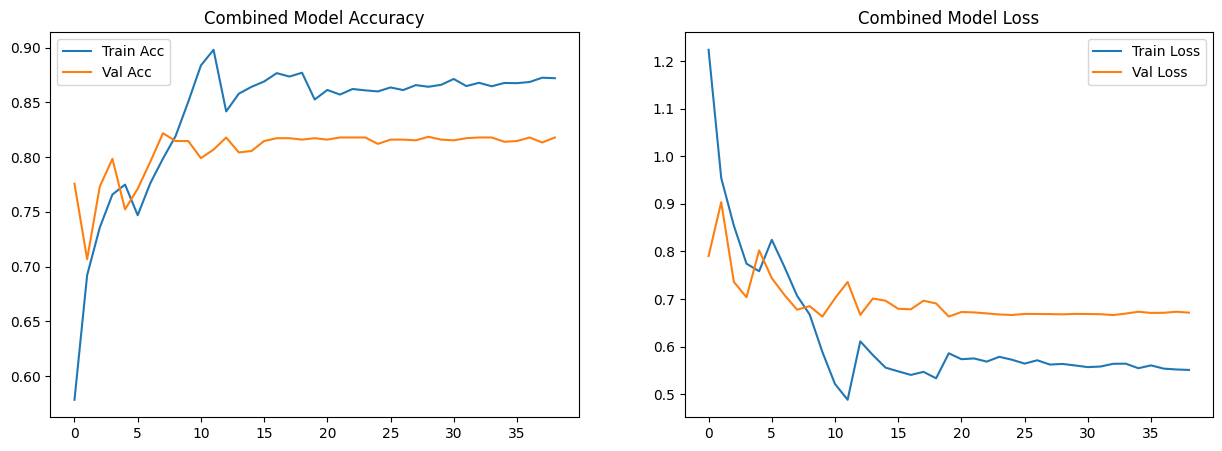

In [12]:
# Cell 9: Plot Training History
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
try:
    plt.plot(history1.history['accuracy'] + history2.history['accuracy'] + history3.history['accuracy'], label='Train Acc')
    plt.plot(history1.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy'], label='Val Acc')
except:
    pass
plt.title('Combined Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
try:
    plt.plot(history1.history['loss'] + history2.history['loss'] + history3.history['loss'], label='Train Loss')
    plt.plot(history1.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss'], label='Val Loss')
except:
    pass
plt.title('Combined Model Loss')
plt.legend()
plt.show()

In [15]:
# Cell 10: Model Ensembling for Maximum Accuracy
import numpy as np
from sklearn.metrics import accuracy_score

print("--- Starting Ensemble Prediction ---")
# Get the true labels from your validation set
val_true = np.argmax(val_labels, axis=1)

print("1. Predicting with Phase 1 Weights...")
model.load_weights('/kaggle/working/models/efficientnet_phase1.keras')
preds_phase1 = model.predict(val_dataset, verbose=1)

print("2. Predicting with Phase 3 Weights...")
model.load_weights('/kaggle/working/models/efficientnet_best.keras')
preds_phase3 = model.predict(val_dataset, verbose=1)

print("3. Averaging the Models together...")
ensemble_preds = (preds_phase1 + preds_phase3) / 2.0
final_predictions = np.argmax(ensemble_preds, axis=1)

# Calculate Final Accuracy!
final_accuracy = accuracy_score(val_true, final_predictions)
print(f"\nFINAL ENSEMBLE ACCURACY: {final_accuracy * 100:.2f}% ")


--- Starting Ensemble Prediction ---
1. Predicting with Phase 1 Weights...
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step
2. Predicting with Phase 3 Weights...
97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step
3. Averaging the Models together...

FINAL ENSEMBLE ACCURACY: 82.05% 


--- Detailed Classification Report ---

                   precision    recall  f1-score   support

        No DR (0)       0.97      0.96      0.97       361
         Mild (1)       0.92      0.86      0.89       563
     Moderate (2)       0.63      0.85      0.72       200
       Severe (3)       0.67      0.66      0.67       213
Proliferative (4)       0.69      0.62      0.65       201

         accuracy                           0.82      1538
        macro avg       0.78      0.79      0.78      1538
     weighted avg       0.83      0.82      0.82      1538


--- Plotting Confusion Matrix ---


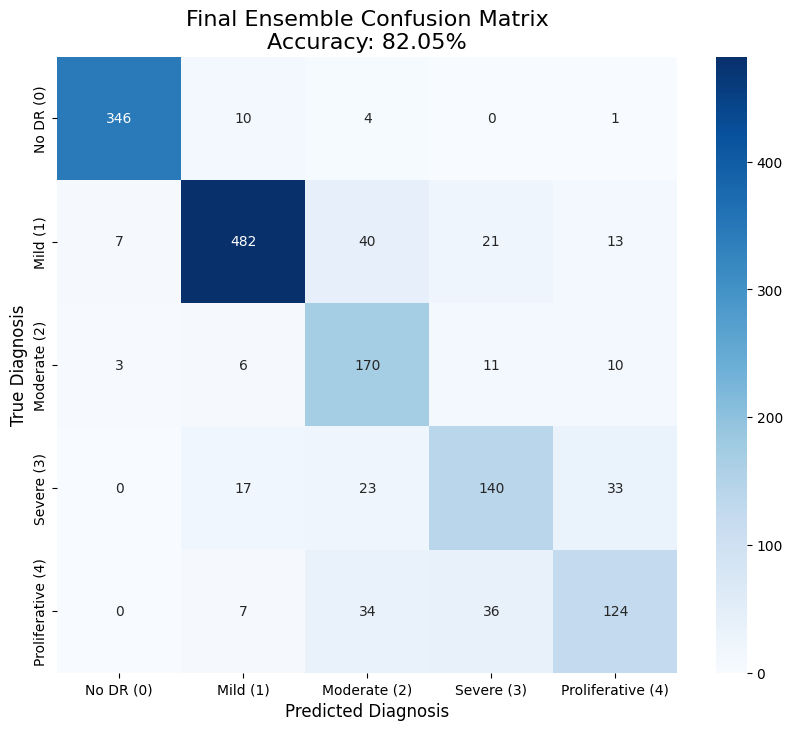

In [16]:
# Cell 11: Confusion Matrix and Classification Report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

target_names = ['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Proliferative (4)']

print("--- Detailed Classification Report ---\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

print("\n--- Plotting Confusion Matrix ---")
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Final Ensemble Confusion Matrix\nAccuracy: {final_accuracy * 100:.2f}%', fontsize=16)
plt.ylabel('True Diagnosis', fontsize=12)
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.show()


In [20]:
# Cell 11: Final Report & Download Links
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
from sklearn.metrics import cohen_kappa_score, f1_score
from IPython.display import FileLink

print("💾 Creating final reports, images, and downloading models...")

# 0. Copy the models exactly to the root directory so Kaggle allows downloading them!
try:
    shutil.copy('/kaggle/working/models/efficientnet_best.keras', 'efficientnet_best.keras')
    shutil.copy('/kaggle/working/models/efficientnet_phase1.keras', 'efficientnet_phase1.keras')
except Exception as e:
    print("Could not copy models. They might already be here, or check folder paths.")

# 1. Calculate final metrics
cm = confusion_matrix(y_true_classes, y_pred_classes)
kappa = cohen_kappa_score(y_true_classes, y_pred_classes, weights='quadratic')
f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')

# 2. SAVE the Confusion Matrix Image
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Prolif. (4)'], 
            yticklabels=['No DR (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)', 'Prolif. (4)'])
plt.title(f'Final Ensemble Confusion Matrix (QWK: {kappa:.4f})', fontsize=16)
plt.ylabel('True Diagnosis', fontsize=12)
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.savefig('final_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.close()

# 3. SAVE the Training History Image
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
try:
    combined_acc = history1.history['accuracy'] + history2.history['accuracy'] + history3.history['accuracy']
    combined_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy'] + history3.history['val_accuracy']
    plt.plot(combined_acc, label='Train Acc')
    plt.plot(combined_val_acc, label='Val Acc')
    plt.title('Accuracy History')
    plt.legend()
except:
    pass

plt.subplot(1, 2, 2)
try:
    combined_loss = history1.history['loss'] + history2.history['loss'] + history3.history['loss']
    combined_val_loss = history1.history['val_loss'] + history2.history['val_loss'] + history3.history['val_loss']
    plt.plot(combined_loss, label='Train Loss')
    plt.plot(combined_val_loss, label='Val Loss')
    plt.title('Loss History')
    plt.legend()
except:
    pass
plt.savefig('training_performance_history.png', bbox_inches='tight', dpi=300)
plt.close()

# 4. Display the Download Links (Only do the tiny images!)
print('\n Results Ready! Click the blue links below to download the reports:')
display(FileLink(r'final_confusion_matrix.png'))
display(FileLink(r'training_performance_history.png'))


print(" Zipping  massive models into a safe package...")

shutil.make_archive('My_Trained_Models', 'zip', '/kaggle/working/models')

print(" Zipping Complete! Click the blue link below to download your models:")
display(FileLink(r'My_Trained_Models.zip'))



💾 Creating final reports, images, and downloading models...

 Results Ready! Click the blue links below to download the reports:


/kaggle/working/final_confusion_matrix.png

/kaggle/working/training_performance_history.png

 Zipping  massive models into a safe package...
 Zipping Complete! Click the blue link below to download your models:


/kaggle/working/My_Trained_Models.zip